# Bragg Peaks and Centering

In this notebook, we are applying centring to the detected Bragg disks (obtained from the [Bragg Disk Detection notebook](https://github.com/2779765h/ACPP/blob/main/Notebooks/1%20-%20Bragg%20Disk%20Detection.ipynb)) and then converting the Bragg disks data into an array list of diffraction values. 

Sources:

Centering uses modified code from:
https://github.com/py4dstem/py4DSTEM_tutorials/blob/main/notebooks/basics_04_strain.ipynb

Function for converting BraggVectors to array (pointlist_to_array) from: https://github.com/maclariz/py4DSTEM/blob/dev/py4DSTEM/process/diffraction/digital_dark_field.py

### Import packages and Bragg peak data

In [1]:
from emdfile import tqdmnd
import numpy as np
import matplotlib.pyplot as plt
import py4DSTEM
from py4DSTEM.visualize import show

C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
C:\Users\alahe\anaconda3\envs\py4dstem\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
CUDA path could not be detected. Set CUDA_PATH

In [2]:
# Import Data
data = "BraggPeakData/Example_braggpeaks.h5"

In [3]:
# Reload
braggpeaks = py4DSTEM.read(data, root='/datacube_root/braggvectors')

Reading PointListArray: 100%|██████████| 900/900 [00:00<00:00, 6558.33PointList/s]


### Centering

This ensures that the central position remains fixed for each diffraction pattern. 

Steps include:
- Calibration of origin
- Fitting a plane to the origin
- Recompute the Bragg disk positions with a Bragg vector map (BVM), using centred origin positions
- Compare to uncalibrated BVM



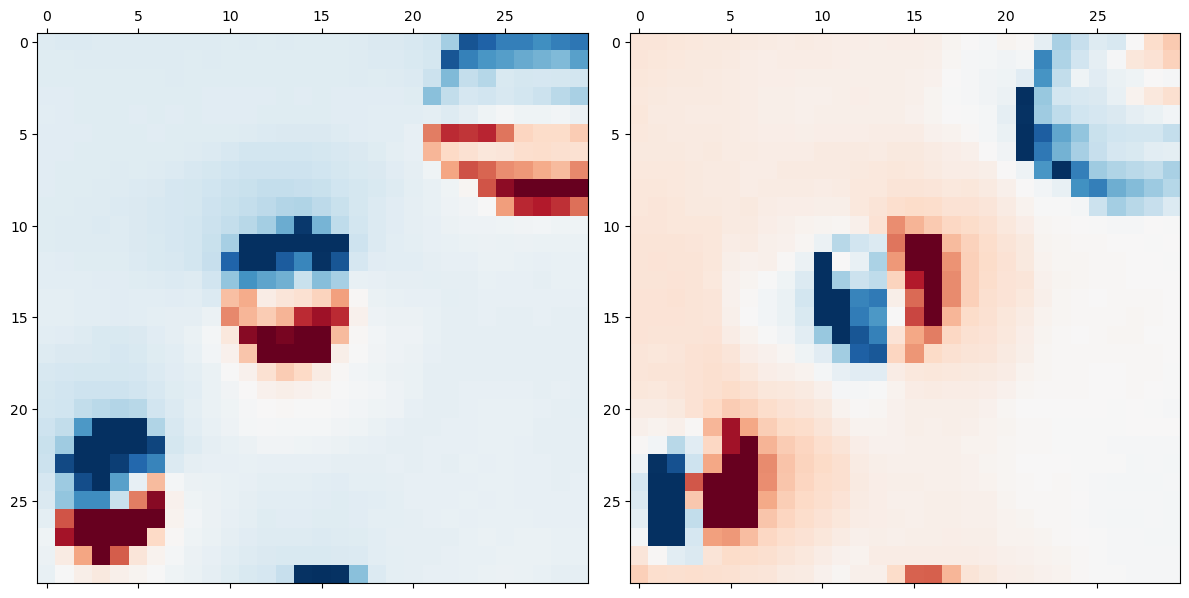

In [4]:
# calibrate the origin
# Measure the origin
qx0_meas,qy0_meas,mask_meas = braggpeaks.measure_origin()

show(
    [qx0_meas,qy0_meas],
    cmap = 'RdBu',
    mask = mask_meas
)

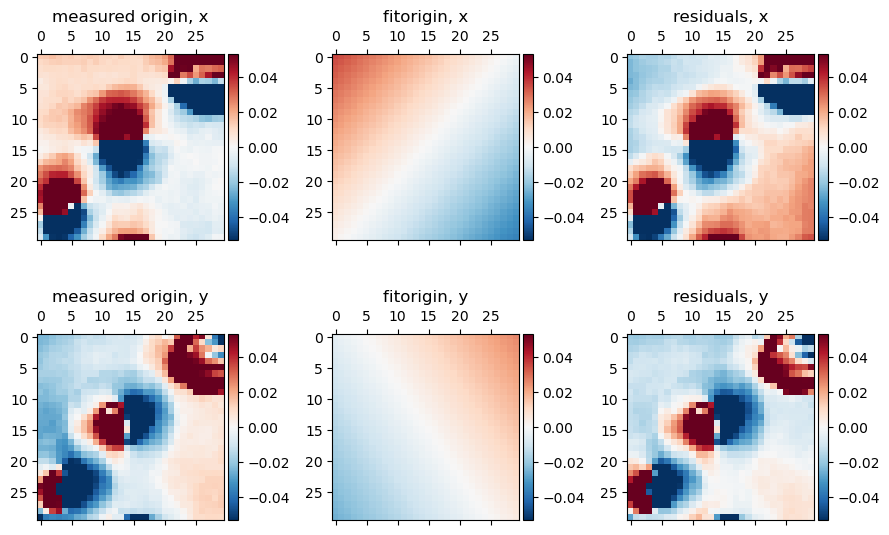

In [5]:
# Fit a plane to the origins
qx0_fit,qy0_fit,qx0_residuals,qy0_residuals = braggpeaks.fit_origin()

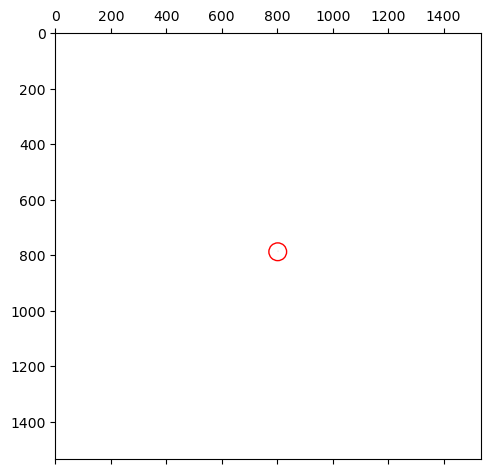

In [6]:
# Now that we've calibrated the center positions, we can re-compute
# the Bragg vector map, this time with the center correction applied
sampling = 8

# compute
bvm = braggpeaks.histogram(
    #mode='cal',             # 'cal' is the default mode, so this line can be included or left out
    sampling = sampling,
)

# show
# overlay a circle around the center for visualization purposes
show(
    bvm,
    circle={
        'center' : bvm.origin,   # the centered BVM knows where its origin is 
        'R' : 4*sampling,
        'fill' : False,
        'linewidth' : 1
    },
    cmap='terrain_r',
    intensity_range='ordered',
    vmin=0,
    vmax= 1 #0.9
)

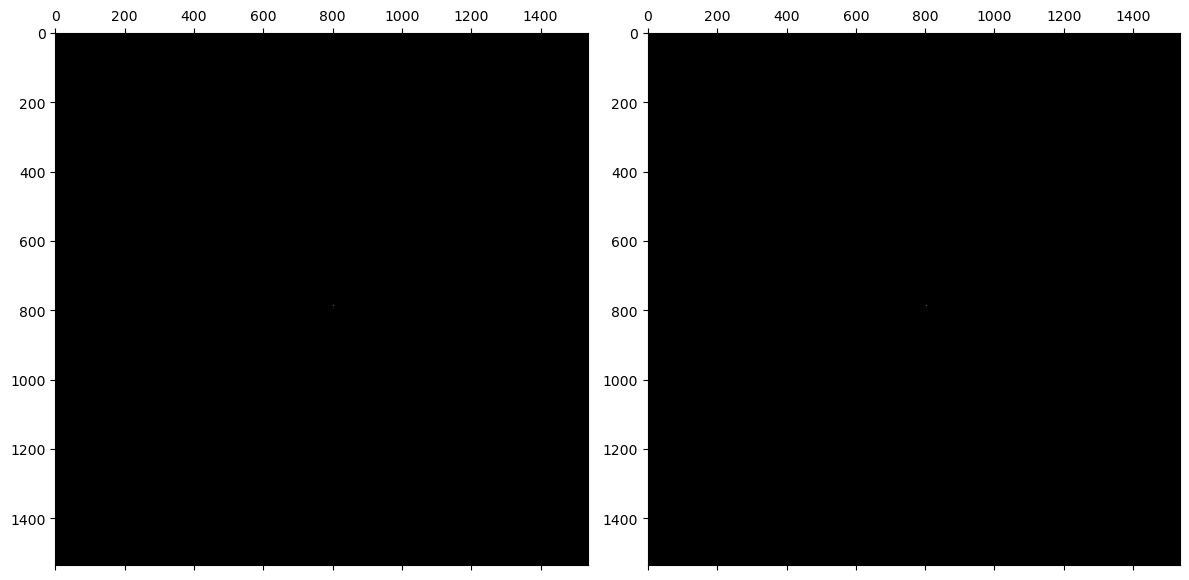

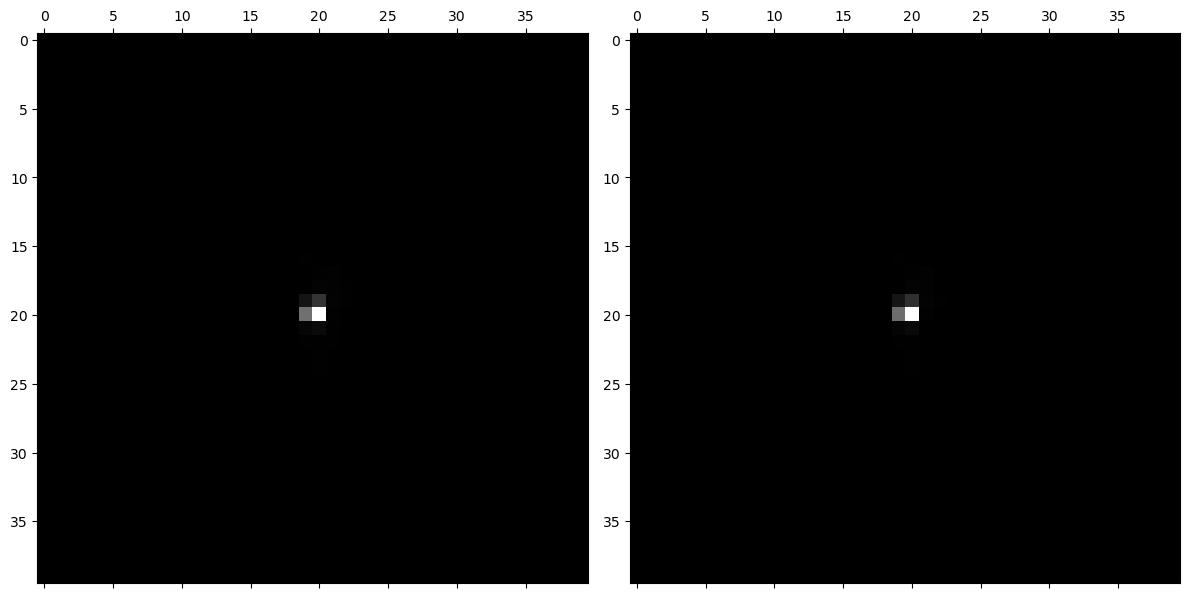

In [7]:
# Compare this to the uncalibrated BVM - much better!
# compute raw vs. centered
bvm_r = braggpeaks.histogram( mode='raw', sampling=sampling )
bvm_c = braggpeaks.histogram( mode='cal', sampling=sampling )

# show
show( [bvm_r, bvm_c] ,vmax=0.999999)

# show, zooming in on origin
L = 20
x,y = bvm_c.origin
import numpy as np
x0,xf = np.round([x-L,x+L]).astype(int)
y0,yf = np.round([y-L,y+L]).astype(int)

show(
    [
    bvm_r[x0:xf,y0:yf],
    bvm_c[x0:xf,y0:yf]
    ],
    vmax=0.8
)

### Converting Bragg peaks into an array list

Following calibration, the detected Bragg peaks can be converted into an array list. The array will contain information of the diffraction space vectors (Qx, Qy), intensity at each point (I), real space coordinates (Rx, Ry), as well as radius and angle in diffraction space (Qr, Qphi) (optional).

The data can also be cut on the radius or angle. In this notebook, we have an example of a radius cut between 1 < Qr < 32, other cuts are also possible.

In [8]:
# Importing function for converting bragg peaks to an arraylist
def pointlist_to_array(
    bragg_peaks,
    center=None, 
    ellipse=None,
    pixel=None,
    rotate=None,
    rphi=True,
):
    """
    This function turns the py4DSTEM BraggVectors to a simple numpy array that is more
    convenient for rapid array processing in numpy

    Parameters
    ----------
    bragg_peaks: BraggVectors
        py4DSTEM BraggVectors
    center: bool
        If True, applies center calibration to bragg_peaks
    ellipse: bool
        if True, applies elliptical calibration to bragg_peaks
    pixel: bool
        if True, applies pixel calibration to bragg_peaks
    rotate: bool
        if True, applies rotational calibration to bragg_peaks
    rphi: bool
        if True, generates two extra columns of Qr and Qphi for addressing in polar
        coordinates, Qphi is the angle in degrees anticlockwise from horizontal to the right

    Returns
    ----------
    points_array: numpy array
         This will be an 2D numpy array of n points x 5 (or 7) columns:
            qx
            qy
            I
            Rx
            Ry
            (qr)
            (qphi)
    """
    if center is None:
        center = bragg_peaks.calstate["center"]

    if ellipse is None:
        ellipse = bragg_peaks.calstate["ellipse"]

    if pixel is None:
        pixel = bragg_peaks.calstate["pixel"]

    if rotate is None:
        rotate = bragg_peaks.calstate["rotate"]

    for i, j in tqdmnd(bragg_peaks.Rshape[0], bragg_peaks.Rshape[1]):
        vectors = bragg_peaks.get_vectors(
            scan_x=i,
            scan_y=j,
            center=center,
            ellipse=ellipse,
            pixel=pixel,
            rotate=rotate,
        )

        if rphi == True:
            if i == j == 0:
                points_array = np.array(
                    [
                        vectors.qx,
                        vectors.qy,
                        vectors.I,
                        vectors.qx.shape[0] * [i],
                        vectors.qx.shape[0] * [j],
                        (vectors.qx**2 + vectors.qy**2) ** 0.5,
                        np.degrees(np.arctan2(-vectors.qx, vectors.qy)),
                    ]
                ).T
            else:
                nps = np.array(
                    [
                        vectors.qx,
                        vectors.qy,
                        vectors.I,
                        vectors.qx.shape[0] * [i],
                        vectors.qx.shape[0] * [j],
                        (vectors.qx**2 + vectors.qy**2) ** 0.5,
                        np.degrees(np.arctan2(-vectors.qx, vectors.qy)),
                    ]
                ).T
                points_array = np.vstack((points_array, nps))

        else:
            if i == j == 0:
                points_array = np.array(
                    [
                        vectors.qx,
                        vectors.qy,
                        vectors.I,
                        vectors.qx.shape[0] * [i],
                        vectors.qx.shape[0] * [j],
                    ]
                ).T
            else:
                nps = np.array(
                    [
                        vectors.qx,
                        vectors.qy,
                        vectors.I,
                        vectors.qx.shape[0] * [i],
                        vectors.qx.shape[0] * [j],
                    ]
                ).T
                points_array = np.vstack((points_array, nps))

    return points_array

In [9]:
# Centre peak positions and convert to pointsarray
PeaksList = pointlist_to_array(braggpeaks,
    center=True, # apply centering
    ellipse=None,
    pixel=None,
    rotate=None,
    rphi=True,
)

100%|██████████| 900/900 [00:00<00:00, 19687.15it/s]


In [11]:
# Apply cuts to PeaksArray 
PeaksArray = PeaksList[(PeaksList[:,5]>1) & (PeaksList[:,5]<32)] 

# Extract values
Qx = PeaksArray[:, 0]
Qy = PeaksArray[:, 1]
Rx = PeaksArray[:, 3]
Ry = PeaksArray[:, 4]

## Save Bragg Peak data as an array 

In [12]:
np.save('data/PeaksArray_SmallRange', PeaksArray)